### Candidate number: 65191

## Assignment 4 (summative)

In Parts 1 and 2, you will use matrix visualisation techniques to explore the Iris dataset and apply different metrics to evaluate clustering and classification of this dataset. In the final part you will explore your chosen dataset from the World Bank website. 

**Please make sure all your plots have appropriate axes labels, titles, and legends (if applicable)!**

In [20]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

## **Part 1**. Iris dataset 
This dataset looks at features of <a href="https://en.wikipedia.org/wiki/Iris_flower_data_set">Iris flowers</a>. The questions ask you to apply standard visualisation techniques to this dataset. First, import and examine the data.


In [21]:
from sklearn.datasets import load_iris

iris = load_iris()
iris_df = pd.DataFrame(
    iris.data, 
    columns=iris.feature_names
)
iris_df['species'] = iris.target
iris_df['species'] = iris_df['species'].map({0: "setosa", 1: "versicolor", 2: "virginica"})
# Shuffle the data
iris_df = iris_df.sample(frac=1, random_state=42)
iris_df.head(5)

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species
73,6.1,2.8,4.7,1.2,versicolor
18,5.7,3.8,1.7,0.3,setosa
118,7.7,2.6,6.9,2.3,virginica
78,6.0,2.9,4.5,1.5,versicolor
76,6.8,2.8,4.8,1.4,versicolor


### Q1. Produce the correlation matrix as a heatmap showing the correlation between the different numeric features of the iris flowers.

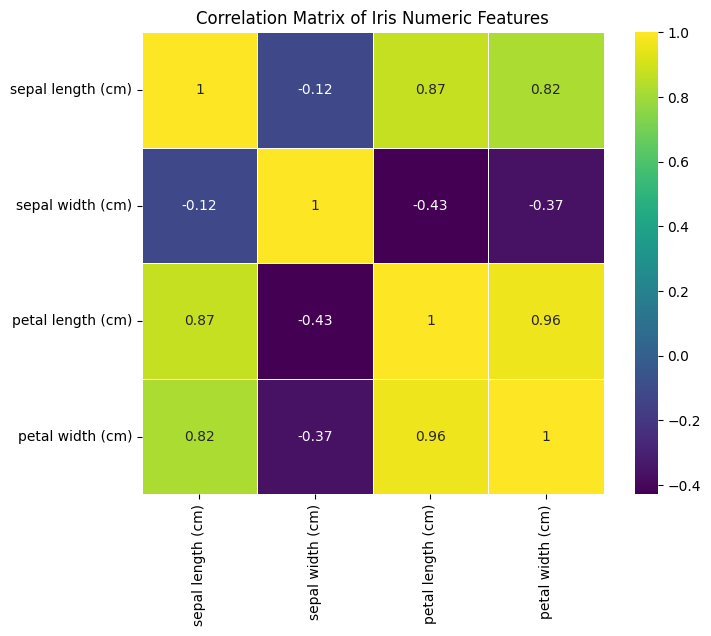

In [6]:
# calc correlation matrix (numeric features only)
corr = iris_df.drop(columns=['species']).corr()

# heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(
    corr, 
    annot=True, 
    cmap="viridis", 
    linewidths=0.5, 
    square=True
)
plt.title("Correlation Matrix of Iris Numeric Features")
plt.show()

### Q2. Produce a pairplot that visualises the iris data features as scatter plots and histograms between different features. Colour the data according to the three types of iris (given in ``iris_df['species']``). The exact layout and use of kernel density estimation (KDE) for some of the plots is up to you.

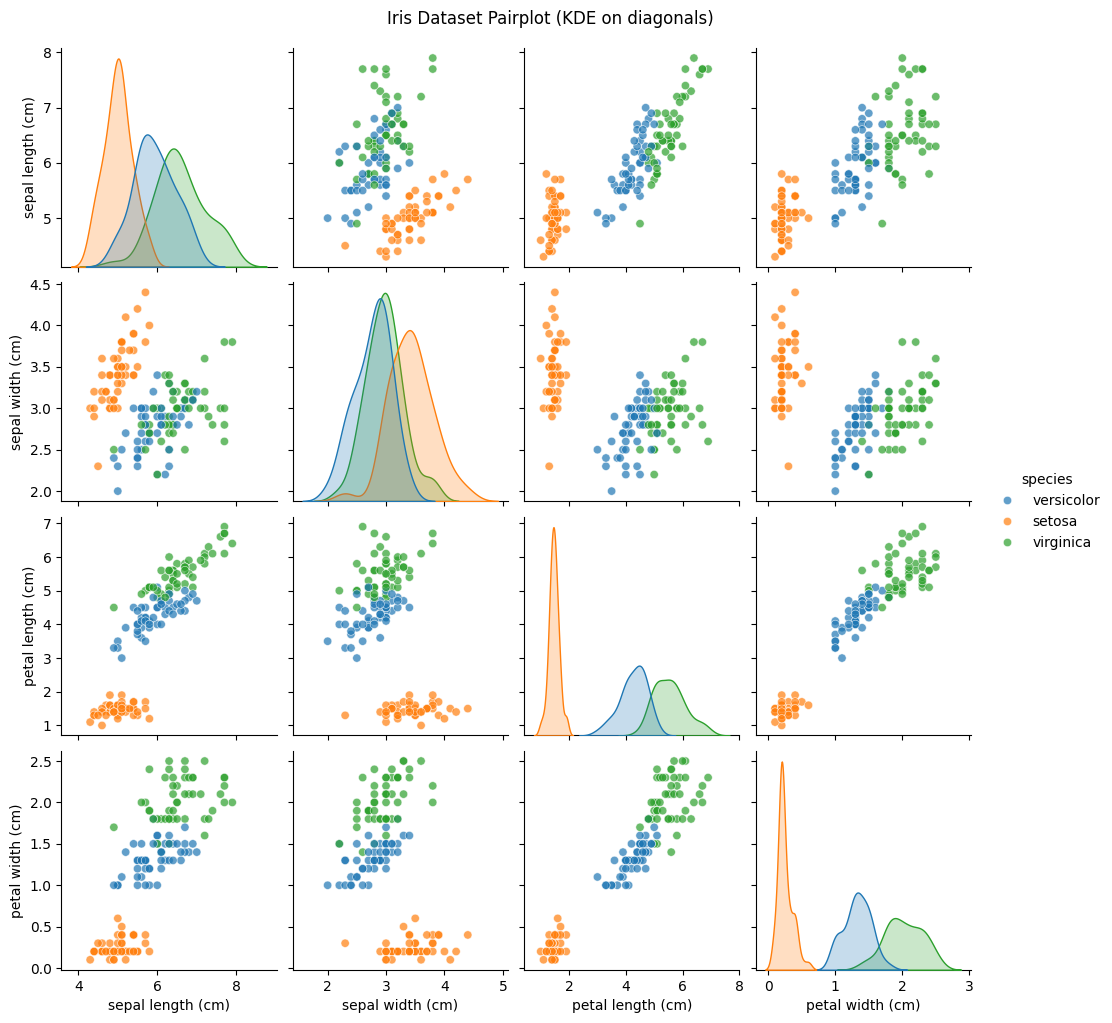

In [11]:
# pairplot of all numeric features coloured by species
sns.pairplot(
    iris_df,
    hue='species',
    diag_kind='kde', # KDE on the diagonal
    corner=False,           
    plot_kws={'alpha': 0.7} 
)

plt.suptitle("Iris Dataset Pairplot (KDE on diagonals)", y=1.02)
plt.show()


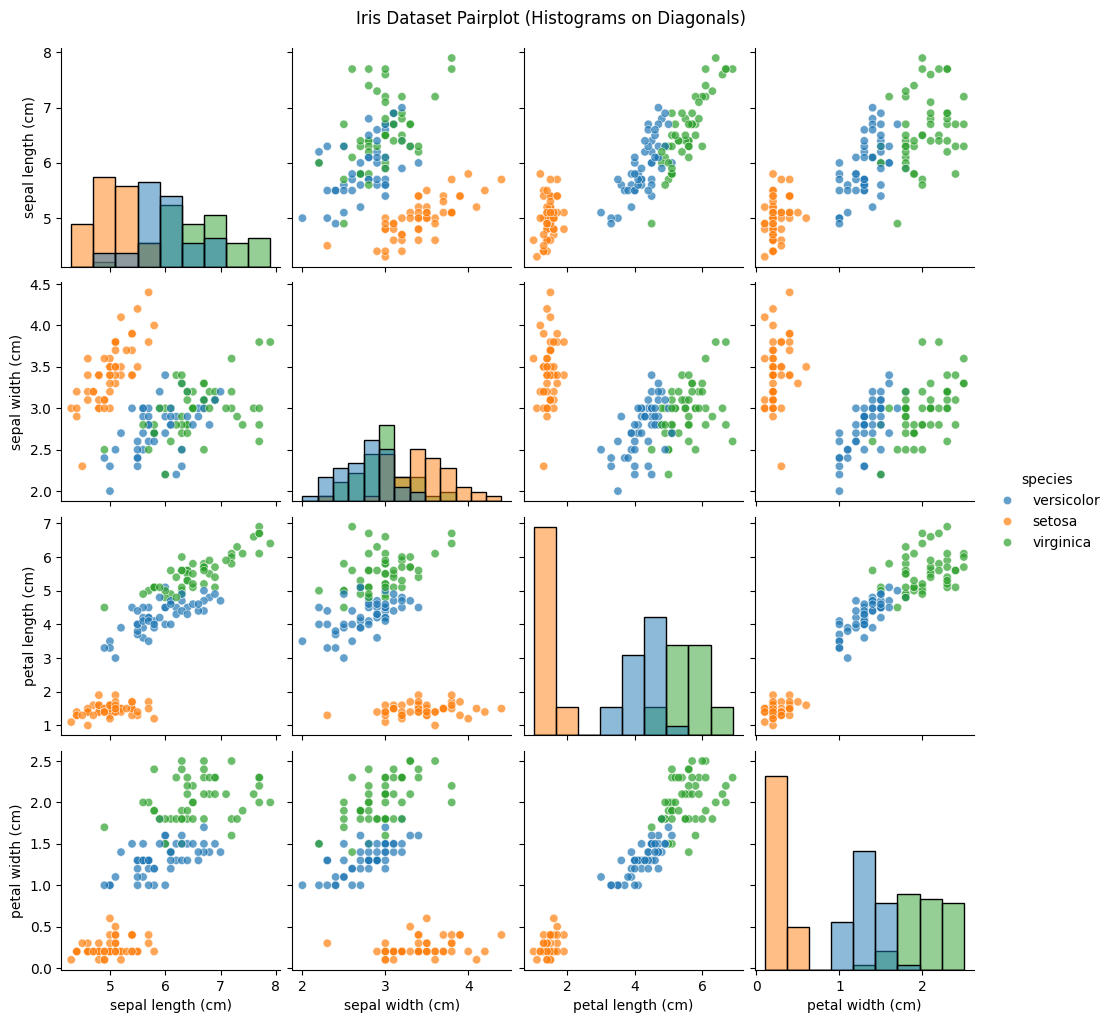

In [10]:
sns.pairplot(
    iris_df,
    hue="species",
    diag_kind="hist",        # Use histograms instead of KDE on the diagonal
    corner=False,
    plot_kws={'alpha': 0.7}
)

plt.suptitle("Iris Dataset Pairplot (Histograms on Diagonals)", y=1.02)
plt.show()

### Q3. Produce a distance matrix between each pair of data points in the iris dataset. Plot the distance matrix as a heatmap.

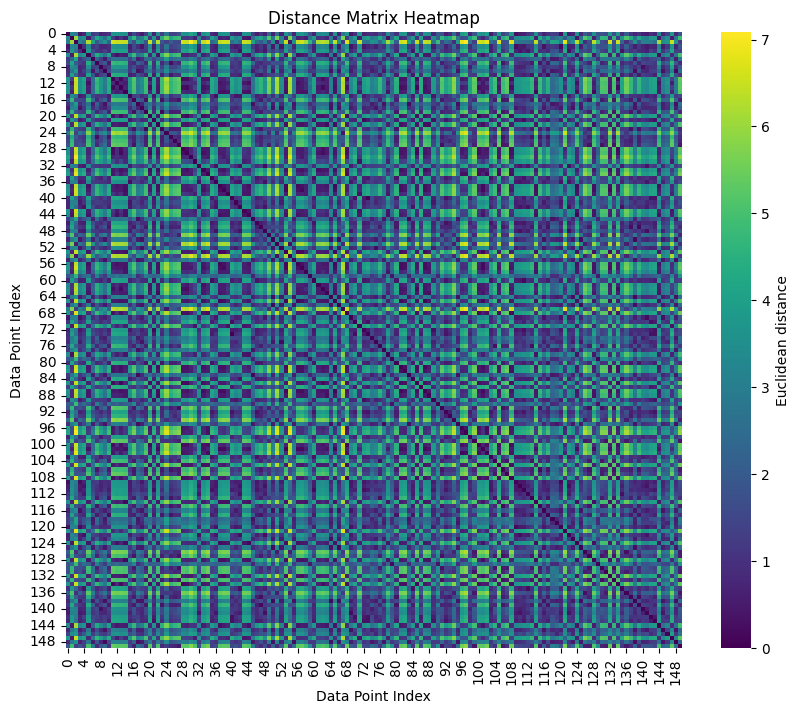

In [12]:
from scipy.spatial.distance import pdist, squareform

# extract numeric features 
X = iris_df.drop(columns=["species"]).values

# compute pairwise Euclidean distances using pdist
dist_condensed = pdist(X, metric='euclidean')

# convert condensed distance matrix to square form
dist_matrix = squareform(dist_condensed)

# convert to DataFrame for clean heatmap labelling
dist_df = pd.DataFrame(dist_matrix)

# heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(
    dist_df,
    cmap="viridis",
    square=True,
    cbar_kws={'label': 'Euclidean distance'}
)
plt.title("Distance Matrix Heatmap")
plt.xlabel("Data Point Index")
plt.ylabel("Data Point Index")
plt.show()

### Q4. Use a clustermap to hierarchically cluster the flowers. The choise of ``method`` (linkage criterion) and ``metric`` (distance between points) is up to you.

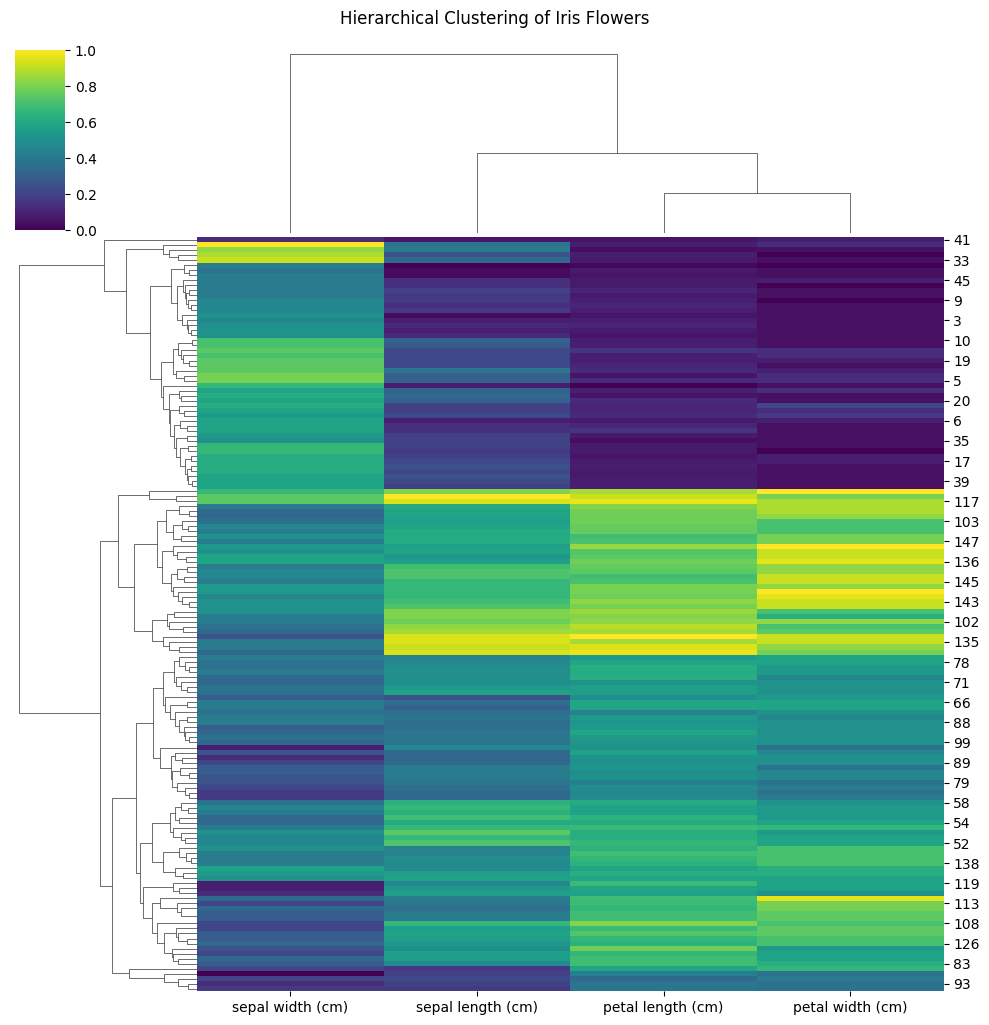

In [15]:
# only the numeric features
X = iris_df.drop(columns=["species"])

# compute distance matrix 
dist_matrix = pdist(X, metric="euclidean")
dist_square = squareform(dist_matrix)

# clustermap with hierarchical clustering
sns.clustermap(
    X,                     
    method="average",      # linkage method
    metric="euclidean",    # distance metric
    cmap="viridis",        
    standard_scale=1       # normalise features to comparable scales
)

plt.suptitle("Hierarchical Clustering of Iris Flowers", y=1.02)
plt.show()

### Q5. Using K-means algorithm from sklearn, cluster the distance data into 3 clusters. Produce a scatter plot for petal width against petal length where each datapoint is colored according to the cluster assignment. Then produce the same scatter plot but use the true labels (``'species``) to colour the datapoints. Do the K-means clusters and the true labales coinside?

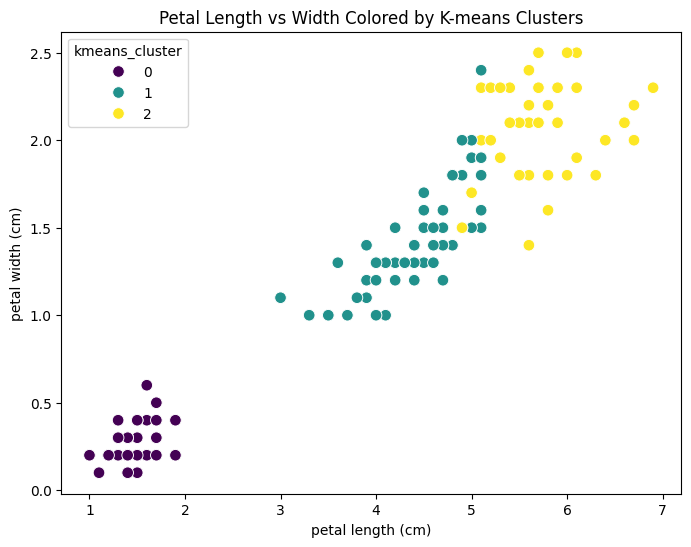

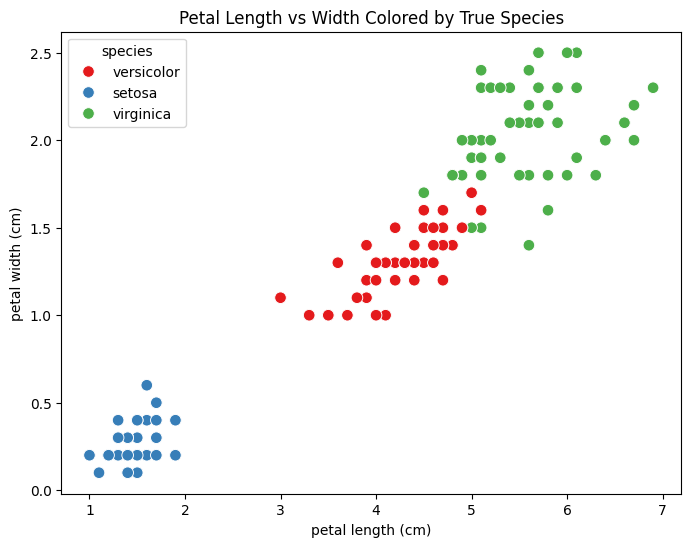

In [22]:
from sklearn.cluster import KMeans

# numeric features for clustering
X = iris_df.drop(columns=["species"])

# K-means with 3 clusters
kmeans = KMeans(n_clusters=3, random_state=42)
iris_df['kmeans_cluster'] = kmeans.fit_predict(X)

# petal length vs petal width (K-means clusters)
plt.figure(figsize=(8, 6))
sns.scatterplot(
    data=iris_df,
    x='petal length (cm)',
    y='petal width (cm)',
    hue='kmeans_cluster',
    palette='viridis',
    s=70
)
plt.title("Petal Length vs Width Colored by K-means Clusters")
plt.show()

# petal length vs petal width (true species)
plt.figure(figsize=(8, 6))
sns.scatterplot(
    data=iris_df,
    x='petal length (cm)',
    y='petal width (cm)',
    hue='species',
    palette='Set1',
    s=70
)
plt.title("Petal Length vs Width Colored by True Species")
plt.show()



### Q6. Evaluate the K-means clustering using one internal metric (silhouette score) and one external metric (Adjusted Rand Index).

1. Compute the **silhouette score** for this clustering using `silhouette_score` from `sklearn`. Report the value and add a short comment (1–2 sentences) about whether this suggests
well-separated clusters.
2. Now compare the K-means clustering to the true species labels using the **Adjusted Rand Index (ARI)**. Compute the ARI with `adjusted_rand_score` from `sklearn`. In 1–2 sentences, explain what this value tells you about how well k-means recovered the true species.

Hint: Use the original features of the Iris dataset (no train/test split needed here).

In [17]:
from sklearn.metrics import silhouette_score
# 1. computing the silhouette score
# features used for clustering
X = iris_df.drop(columns=['species', 'kmeans_cluster'])

# cluster labels from K-means
labels = iris_df['kmeans_cluster']

# silhouette score
score = silhouette_score(X, labels)
print(f"Silhouette Score: {score:.3f}")


Silhouette Score: 0.553


The silhouette score of 0.553 shows that the clusters are well separated, but they are not perfectly separated. The setosa cluster is very distinct but we can see some overlap between the versicolor and virginica clusters which probably has lowered our silhouette score.

In [23]:
# 2. computing the adjusted rand index
from sklearn.metrics import adjusted_rand_score

# true labels (encoded as integers)
true_labels = iris_df['species'].map({"setosa": 0, "versicolor": 1, "virginica": 2})

# K-means cluster labels
kmeans_labels = iris_df['kmeans_cluster']

# Compute ARI
ari = adjusted_rand_score(true_labels, kmeans_labels)
print(f"Adjusted Rand Index (ARI): {ari:.3f}")



Adjusted Rand Index (ARI): 0.730


The ARI of 0.730 shows a strong agreement btw the k-means clusters and the true data lables. This score indicates that the clustering was able to correctly separate the setosa species, but had some overlap between the other two species as they are very similar.

## **Part 2**. Classification Metrics on the Iris Dataset

Now evaluate a classifier trained on the **Iris** dataset using several metrics discussed in the lectures.

### Q1. Train–test split and classifier

1. Use the Iris dataset from `sklearn.datasets.load_iris`.
2. Split the data into **train** and **test** sets using `train_test_split` from `sklearn`. Use 50/50 train and test split, `random_state=124791`, `stratify=None`.
3. Train a **logistic regression** classifier from `sklearn` on the training set.


In [27]:
from sklearn.datasets import load_iris
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

# reloading irish dataset from part 1
iris = load_iris()
iris_df = pd.DataFrame(
    iris.data, 
    columns=iris.feature_names
)
iris_df['species'] = iris.target
iris_df['species'] = iris_df['species'].map({0: "setosa", 1: "versicolor", 2: "virginica"})
# Shuffle the data
iris_df = iris_df.sample(frac=1, random_state=42)
# iris_df.head(5)


# Features and labels
X = iris_df[iris.feature_names]
y = iris_df['species']

# Train-test split (50/50)
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.5,
    random_state=124791,
    stratify=None   # as requested
)

# Train logistic regression
clf = LogisticRegression(max_iter=200)  # increase max_iter to ensure convergence
clf.fit(X_train, y_train)

# Predict on test set
y_pred = clf.predict(X_test)

# Evaluate
accuracy = accuracy_score(y_test, y_pred)
print(f"Test Accuracy: {accuracy:.3f}")

Test Accuracy: 0.893


### Q2. Confusion matrix and basic metrics

Using the test set predictions `y_pred` and true labels `y_test`:

1. Compute and plot the confusion matrix.
2. Compute the following metrics for the test set (recall this is a **multiclass** problem):
   - Accuracy
   - Averaged precision (set `average='macro'`)
   - Averaged recall (set `average='macro'`)
   - Averaged F1-score (set `average='macro'`)

Print the values clearly. You may use the metric functions from `sklearn.metrics`.

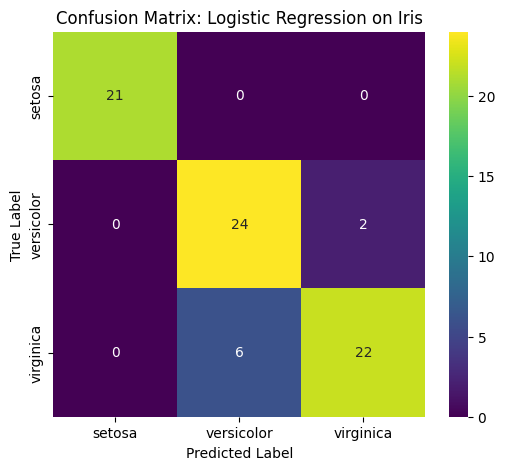

Test Accuracy: 0.893
Macro-Averaged Precision: 0.906
Macro-Averaged Recall: 0.903
Macro-Averaged F1-score: 0.901


In [29]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score

# confusion matrix
cm = confusion_matrix(y_test, y_pred, labels=["setosa", "versicolor", "virginica"])

# plot confusion matrix as heatmap
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="viridis",
            xticklabels=["setosa", "versicolor", "virginica"],
            yticklabels=["setosa", "versicolor", "virginica"])
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix: Logistic Regression on Iris")
plt.show()

# compute metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average='macro')
recall = recall_score(y_test, y_pred, average='macro')
f1 = f1_score(y_test, y_pred, average='macro')

# print metrics
print(f"Test Accuracy: {accuracy:.3f}")
print(f"Macro-Averaged Precision: {precision:.3f}")
print(f"Macro-Averaged Recall: {recall:.3f}")
print(f"Macro-Averaged F1-score: {f1:.3f}")



### Q3. ROC and Precision–Recall curves for one class

Pick one iris species (choose **virginica**, which is class label 2).
Turn the 3-class problem into a **binary** problem for this class (one-vs-rest), and:

1. Compute predicted probabilities for the positive class using `predict_proba` function for the logistic regression.
2. Plot the ROC curve and report the AUC.
3. Plot the Precision–Recall curve.

Plot ROC and PR figures side by side. Label the axes clearly.

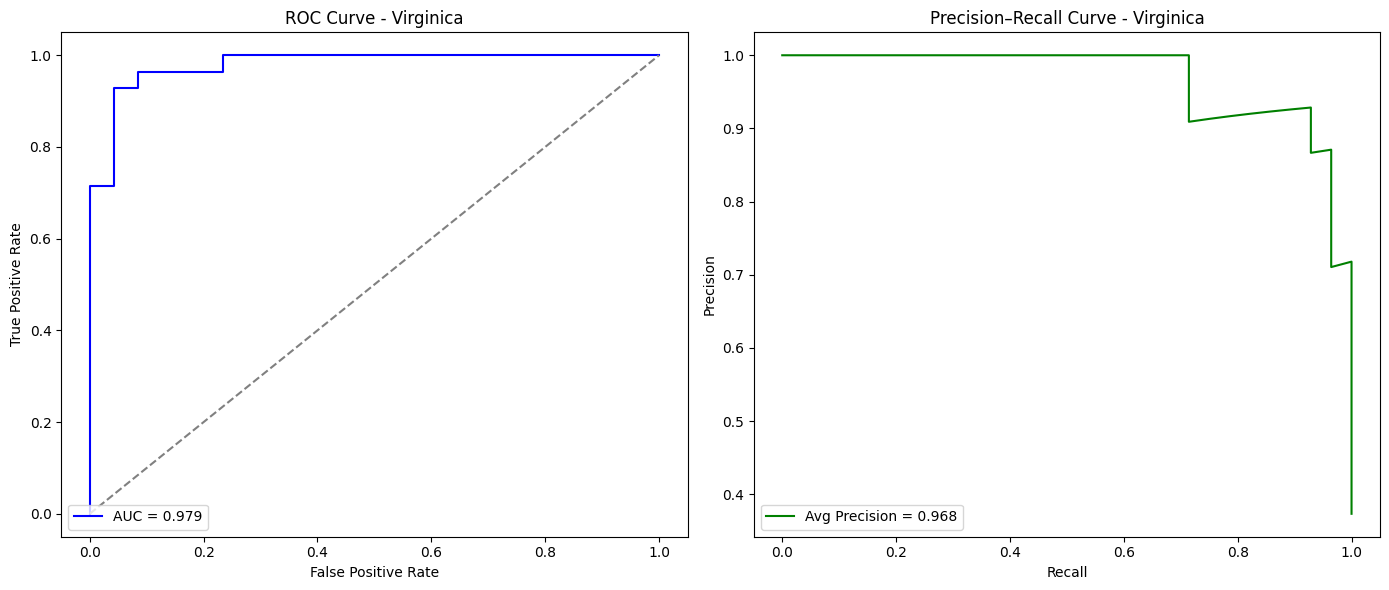

In [32]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc, precision_recall_curve, average_precision_score
from sklearn.linear_model import LogisticRegression

# creating binary labels: virginica = 1, others = 0
y_binary = (y == "virginica").astype(int)
y_test_binary = (y_test == "virginica").astype(int)

# train one-vs-rest logistic regression
clf_binary = LogisticRegression(max_iter=200)
clf_binary.fit(X_train, y_binary[X_train.index])

# predicted probabilities for positive class
y_prob = clf_binary.predict_proba(X_test)[:, 1]

# ROC metrics
fpr, tpr, _ = roc_curve(y_test_binary, y_prob)
roc_auc = auc(fpr, tpr)

# PR metrics
precision, recall, _ = precision_recall_curve(y_test_binary, y_prob)
avg_precision = average_precision_score(y_test_binary, y_prob)

# plot curves side by side
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# ROC curve
axes[0].plot(fpr, tpr, color='blue', label=f"AUC = {roc_auc:.3f}")
axes[0].plot([0, 1], [0, 1], color='gray', linestyle='--')
axes[0].set_xlabel("False Positive Rate")
axes[0].set_ylabel("True Positive Rate")
axes[0].set_title("ROC Curve - Virginica")
axes[0].legend(loc="lower left")

# Precision–Recall curve
axes[1].plot(recall, precision, color='green', label=f"Avg Precision = {avg_precision:.3f}")
axes[1].set_xlabel("Recall")
axes[1].set_ylabel("Precision")
axes[1].set_title("Precision–Recall Curve - Virginica")
axes[1].legend(loc="lower left")

plt.tight_layout()
plt.show()


Both the AUC and average precision rate are close to 1 which indicates the model is very effective at identifying virginica. The model is very good at distinguishing virginica from setosa and versicolor, but there are slight imperfections where virginica and versicolor overlap in the feature space.


## **Part 3**. You are asked to choose 3-4 indicators (economic, development, education, environmental, etc) from the <a href="https://data.worldbank.org/">World Bank dataset</a> and produce **exactly three** plots that explore your chosen data. In the conclusion, communicate 1-2 main points from this data exploration as clearly as possible using your plots as evidence.
Hint 1: For example, you may choose CO2 Emissions per Capita, Renewable Energy Consumption and Forest Area and explore the correlations between these variables. Or, you may choose Life Expectancy, Health Expenditure per Capita, and Infant Mortality Rate and cluster all countries based on these variables. Please do not include too many variables/attributes; 3-4 is enough. You may choose how many countries or what time frame you want to examine. You may explore and download the data using <a href="https://data360.worldbank.org/en/search">Data 360  on World Bank</a>.

Hint 2: At least 2 out of 3 plots should visualise matrix data. The other plot may show time series, barplots, histograms or any other plot that you feel helps you explain or explore your chosen data.

Hint 3: You may download the data from the website as csv files and include it in the submission folder or you may scrape the data using one of the methods discussed in the previous lectures so the data is accessed directly from the web.

Hint 4: Please write a very short description/caption of each figure (no more than 2 sentences!) and a short conclusion at the end (no more than 3-4 sentences!). You may include these as Markdown cells in your notebook where appropriate (e.g. just before or just after the figures).

In [2]:
# loading in 3 datasets for population (millions), gen gov total expenditure (percent of gdp) and unemployment (percent of total labor)
import pandas as pd
df_gdp = pd.read_csv("GDP_data.csv")


# keep only the useful columns
year_cols = [str(y) for y in range(2020, 2026)]

cols_to_keep = ["REF_AREA", "REF_AREA_LABEL"] + year_cols
dfg = df_gdp[cols_to_keep].copy()


# remove duplicate rows per country.
dfg = dfg.groupby(["REF_AREA", "REF_AREA_LABEL"]).max().reset_index()

dfg_long = dfg.melt(
    id_vars=["REF_AREA", "REF_AREA_LABEL"],
    value_vars=year_cols,
    var_name="year",
    value_name="gov_expenditure_gdp"
)

# convert year to int
dfg_long["year"] = dfg_long["year"].astype(int)

# drop missing values
dfg_long = dfg_long.dropna(subset=["gov_expenditure_gdp"])

# rename columns for consistency
dfg_long = dfg_long.rename(columns={"REF_AREA": "country_code",
                                    "REF_AREA_LABEL": "country"})

dfg_long.head()

,country_code,country,year,gov_expenditure_gdp
0,ABW,Aruba,2020,40.237
1,AFG,Afghanistan,2020,27.937
2,AGO,Angola,2020,23.277
3,ALB,Albania,2020,32.552
4,AND,Andorra,2020,42.336


In [3]:
import pandas as pd

df_pop = pd.read_csv("population.csv")
year_cols = [str(y) for y in range(2020, 2026)]

cols_to_keep = ["REF_AREA", "REF_AREA_LABEL"] + year_cols
dfp = df_pop[cols_to_keep].copy()

# one row per country
dfp = dfp.groupby(["REF_AREA", "REF_AREA_LABEL"]).max().reset_index()

dfp_long = dfp.melt(
    id_vars=["REF_AREA", "REF_AREA_LABEL"],
    value_vars=year_cols,
    var_name="year",
    value_name="population_millions"
)

# convert year to integer
dfp_long["year"] = dfp_long["year"].astype(int)

# drop missing values
dfp_long = dfp_long.dropna(subset=["population_millions"])

# rename columns for consistency
dfp_long = dfp_long.rename(columns={"REF_AREA": "country_code",
                                    "REF_AREA_LABEL": "country"})

dfp_long.head()


,country_code,country,year,population_millions
0,ABW,Aruba,2020,0.109
1,AFG,Afghanistan,2020,32.941
2,AGO,Angola,2020,33.428
3,ALB,Albania,2020,2.878
4,AND,Andorra,2020,0.078


In [4]:
df_unemployment = pd.read_csv("unemployment.csv")

year_cols = [str(y) for y in range(2020, 2026)]
cols_to_keep = ["REF_AREA", "REF_AREA_LABEL"] + year_cols

dfu = df_unemployment[cols_to_keep].copy()

dfu = dfu.groupby(["REF_AREA", "REF_AREA_LABEL"]).max().reset_index()

dfu_long = dfu.melt(
    id_vars=["REF_AREA", "REF_AREA_LABEL"],
    value_vars=year_cols,
    var_name="year",
    value_name="unemployment_rate"
)

# convert year to integer
dfu_long["year"] = dfu_long["year"].astype(int)

# drop missing unemployment values
dfu_long = dfu_long.dropna(subset=["unemployment_rate"])

# renaming for consistent merge
dfu_long = dfu_long.rename(columns={
    "REF_AREA": "country_code",
    "REF_AREA_LABEL": "country"
})

dfu_long.head()

,country_code,country,year,unemployment_rate
0,ABW,Aruba,2020,8.600
1,ALB,Albania,2020,11.675
2,AND,Andorra,2020,2.925
3,ARG,Argentina,2020,11.550
4,ARM,Armenia,2020,18.200


In [27]:
# merging clean datasets
# merge population and government expenditure
df_merged = dfp_long.merge(
    dfg_long,
    on=["country_code", "country", "year"],
    how="inner"
)

# merge unemployment
df_merged = df_merged.merge(
    dfu_long,
    on=["country_code", "country", "year"],
    how="inner"
)

df_merged.head(5)

,country_code,country,year,population_millions,gov_expenditure_gdp,unemployment_rate
0,ABW,Aruba,2020,0.109,40.237,8.600
1,ALB,Albania,2020,2.878,32.552,11.675
2,AND,Andorra,2020,0.078,42.336,2.925
3,ARG,Argentina,2020,45.377,42.479,11.550
4,ARM,Armenia,2020,2.962,30.648,18.200


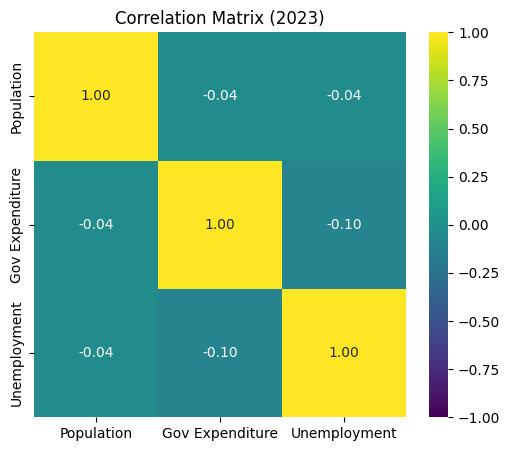

In [28]:
import matplotlib.pyplot as plt
import seaborn as sns

# filter for 2023
df_2023 = df_merged[df_merged['year'] == 2023][
    ['population_millions', 'gov_expenditure_gdp', 'unemployment_rate']
]

# Rename columns
variable_names = {
    'population_millions': 'Population',
    'gov_expenditure_gdp': 'Gov Expenditure',
    'unemployment_rate': 'Unemployment'
}
df_2023 = df_2023.rename(columns=variable_names)

# compute correlation matrix
corr = df_2023.corr()

# heatmap
plt.figure(figsize=(6, 5))
sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap="viridis",
    vmin=-1,
    vmax=1,
    annot_kws={"size": 10}
)
plt.title("Correlation Matrix (2023)")
plt.show()


In 2023, across all countries, there was very little correlation among population (millions), the unemployment rate and government expenditure as a percent of GDP. The stronges correlation was between unemployment and gov expenditure with a -0.10 correlation. This shows that as gov expenditure increases, the unemployment rate tends to decrease, but the relationship between the two is fairly weak.

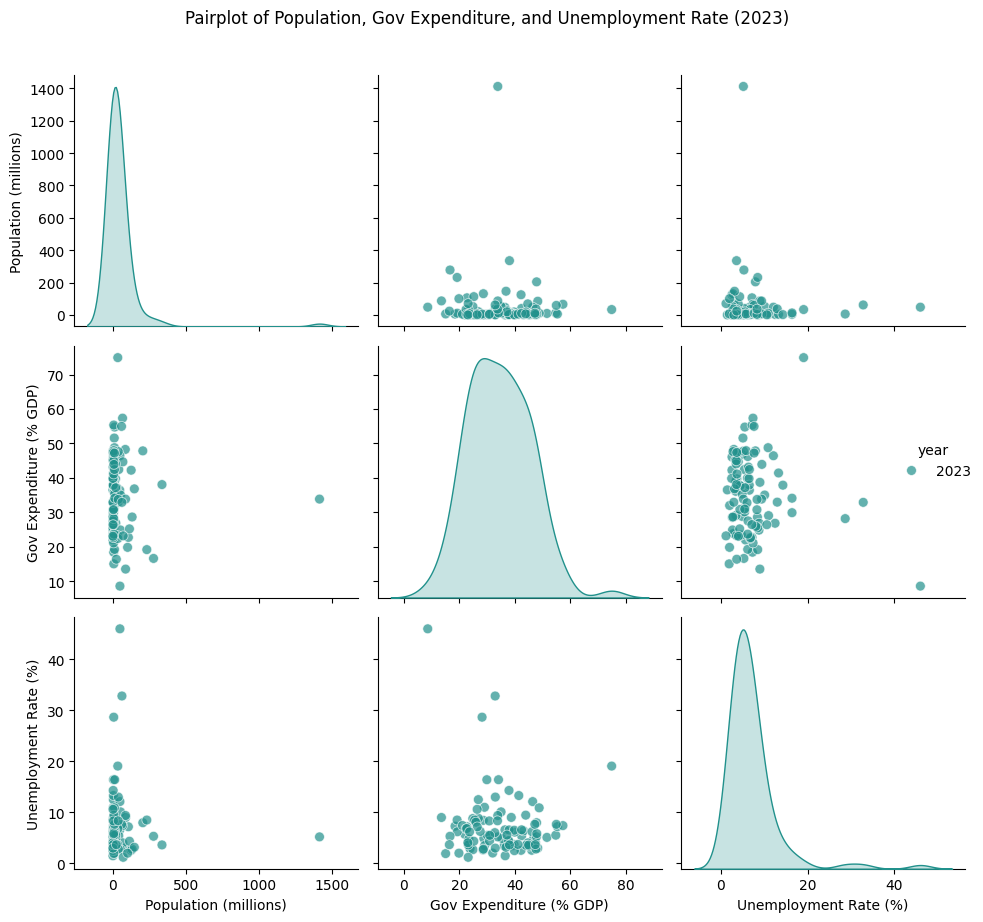

In [29]:
import seaborn as sns
import matplotlib.pyplot as plt

df_pair = df_merged[df_merged['year'] == 2023][['population_millions', 'gov_expenditure_gdp', 'unemployment_rate', 'year']]

# rename columns
df_pair = df_pair.rename(columns={
    'population_millions': 'Population (millions)',
    'gov_expenditure_gdp': 'Gov Expenditure (% GDP)',
    'unemployment_rate': 'Unemployment Rate (%)'
})

# convert year to string 
df_pair['year'] = df_pair['year'].astype(str)

# pairplot 
sns.pairplot(
    df_pair,
    hue='year',  
    palette='viridis',
    diag_kind='kde',
    plot_kws={'alpha':0.7, 's':50},
    height=3
)

plt.suptitle("Pairplot of Population, Gov Expenditure, and Unemployment Rate (2023)", y=1.02)
plt.tight_layout()
plt.show()

From this pairplot we can see that the population data is slightly skewed right which means there are more countries with lower populations and a few with a high population. Similarly with the unemployment rate we can see that there are very few countries with a high unemployment rate.

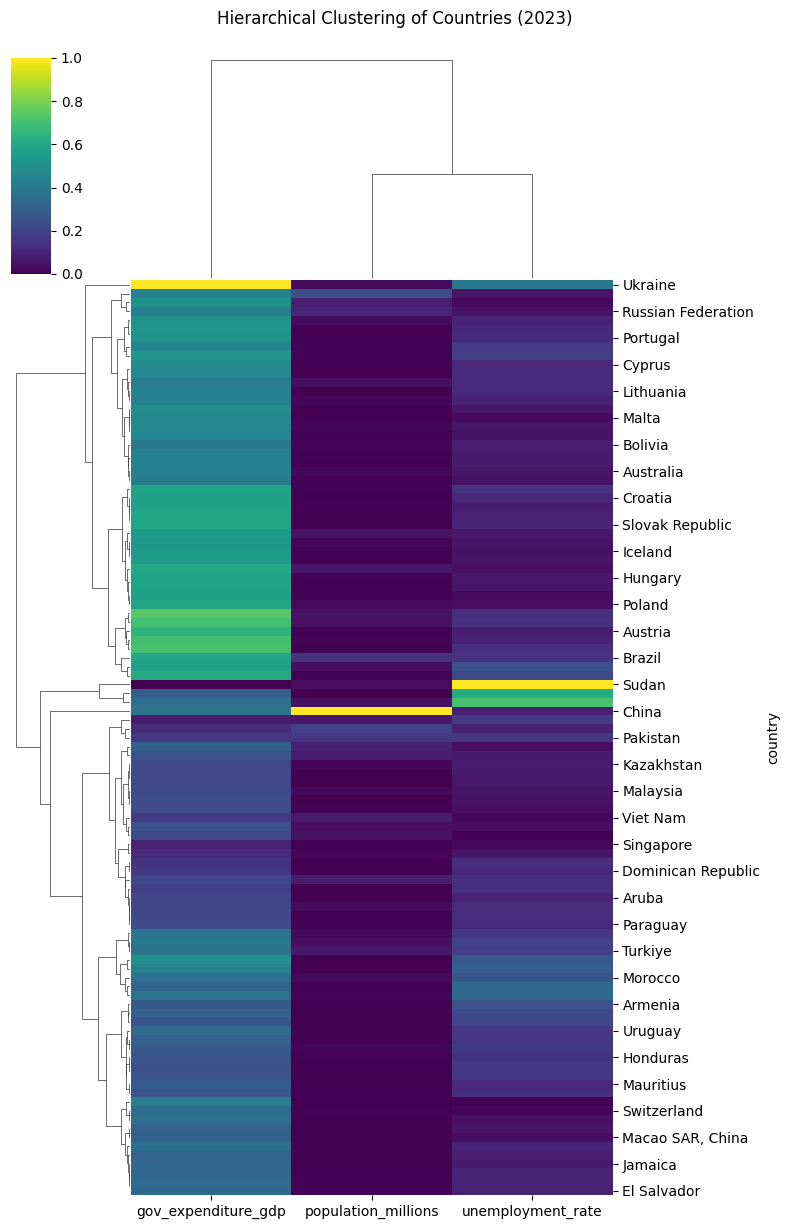

In [41]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans


df_2 = df_merged[df_merged['year'] == 2023][
    ['country', 'population_millions', 'gov_expenditure_gdp', 'unemployment_rate']
]

# select features to cluster
features = ['population_millions', 'gov_expenditure_gdp', 'unemployment_rate']
X = df_2[features]

# scale features 
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# convert back to DataFrame for seaborn
df_scaled = pd.DataFrame(X_scaled, columns=features, index=df_2['country'])
# clustermap
sns.clustermap(
    df_scaled,
    metric='euclidean',
    method='ward',
    cmap='viridis',
    standard_scale=1,
    figsize=(8, 12)
)
plt.suptitle("Hierarchical Clustering of Countries (2023)", y=1.02)
plt.show()

From this hierarchical cluster plot we can see that the majority of the plot is purple (0.0) value indicating very little relation among the countries for the three variables. There is not much we can tell from this plot other than if we performed k-means clustering there would not be very distinct clusters.

In conlcusion, while I expected there to be a negative relationship between unemployment and gov expenditure and a positive relationship between population and unemployment rate, my graphs showed that there is very little relation among the three variables for the year of 2023. If we were to continue the analysis, I would maybe focus on countries with higher population to see if there is some clustering amongst region or cultural aspects. Overall, the three graphs fail to really show similarities between the three variables leading me to assume that there is no/very little correlation among them. (I did perform k-means just to check, and there were only two clusters with cluster 1 only containing three data points, confirming my assumtion.

AI Ackowledgement: I acknowledge the use of ChatGPT (https://chatgpt.com/) for debugging my code as well as asking for python syntax help. I also used ChatGPT to clarify some of the questions (ex what are some examples of plots that visualize matrix data?).